In [1]:
# load last file


import re
from pathlib import Path
import tarfile
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapesimilarity import shape_similarity
from scipy.spatial import procrustes
# from scipy.spatial.distance import cdist
# 
# from scipy.spatial import Voronoi

from scipy.stats import qmc

from scipy.spatial import KDTree

In [3]:

################################
# type funcs
################################
def get_cell_type(cell_id):
    p = cell_id // 2
    part = cell_id % 2  # 0=.re, 1=.im

    if p % 3 == 0:
        return 2 if part == 0 else 5
    elif p % 3 == 1:
        return 3 if part == 0 else 4
    else:
        return 1 if part == 0 else 6
    
    
def get_cell_type_TS(cell_id):
    p = cell_id // 2
    part = cell_id % 2  # 0=.re, 1=.im

    if p % 3 == 0:
        return 5 if part == 0 else 2
    elif p % 3 == 1:
        return 4 if part == 0 else 3
    else:
        return 6 if part == 0 else 1



In [4]:


NX, NY = 576, 576
# NX, NY = 512, 512    
TYPE_COLORS = {
    1: (0.0, 1.0, 1.0),  # cyan
    2: (0.0, 1.0, 0.0),  # grün
    3: (1.0, 0.0, 0.0),  # rot
    4: (1.0, 1.0, 0.0),  # gelb
    5: (0.0, 1.0, 0.0),  # grün
    6: (0.0, 1.0, 1.0),  # cyan
}

################################
# type funcs (for frames)
################################
def get_cell_c(cell_id):
    
    
    p = cell_id // 2 #which pair 
    part = cell_id % 2   #re/im

    if p % 3 == 0:
        return TYPE_COLORS[2] if part == 0 else TYPE_COLORS[5]
    elif p % 3 == 1:
        return TYPE_COLORS[3] if part == 0 else TYPE_COLORS[4]
    else:
        return TYPE_COLORS[1] if part == 0 else TYPE_COLORS[6]
    
def get_cell_c_TS(cell_id):
    
    
    p = cell_id // 2 #which pair 
    part = cell_id % 2   #re/im

    if p % 3 == 0:
        return TYPE_COLORS[5] if part == 0 else TYPE_COLORS[2]
    elif p % 3 == 1:
        return TYPE_COLORS[4] if part == 0 else TYPE_COLORS[3]
    else:
        return TYPE_COLORS[6] if part == 0 else TYPE_COLORS[1]
    
def fields_to_rgb_area(fields, colours):

    rgb = np.zeros((NY, NX, 3), dtype=np.float32)

    for field, colour in zip(fields, colours):

        #border visible w. error
        # f = ((field - 0.5) > 0).astype(np.float32)
        field_max = np.max(field)
        if field_max >=0.5:
            f = (field >= field_max - 0.5).astype(np.float32)
        else:
            f=0

        rgb[..., 0] += f * colour[0]
        rgb[..., 1] += f * colour[1]
        rgb[..., 2] += f * colour[2]

    rgb = np.clip(rgb, 0.0, 1.0)

    frame = (rgb * 255).astype(np.uint8)

    return frame

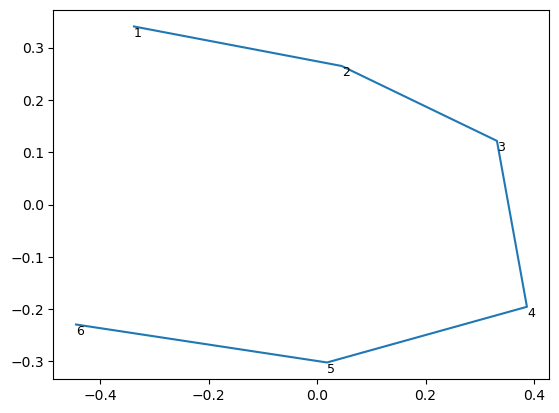

In [5]:
################################
#reference shape (local)
################################
#ref_ts = np.array([1, 2, 3, 4, 5, 6])
ref_ts=np.array([6,5,4,3,2,1])
ref_order = np.argsort(ref_ts)
#from data
# x_compare=[-0.337638,0.045318,0.331642,0.386951,0.018275,-0.444548]
# y_compare =[-0.340506,-0.264926,-0.121715,0.195594,0.302092,0.229461]

#from data
x_compare = [-0.444548, 0.018275, 0.386951, 0.331642, 0.045318, -0.337638]
y_compare = [-0.229461, -0.302092, -0.195594, 0.121715, 0.264926, 0.340506]

xs_ref = np.array(x_compare)[ref_order]
ys_ref = np.array(y_compare)[ref_order]
ref_ts_sort=np.array(ref_ts)[ref_order]
reference_hex= list(zip(xs_ref, ys_ref))
ref = np.array(reference_hex)

plt.plot(xs_ref, ys_ref)
for t, x, y in zip(ref_ts_sort, xs_ref, ys_ref):
    plt.text(x, y, str(t), fontsize=9, ha="left", va="top")
    

################################
#reference shape (global)
################################
#1 - "WRONG" ORIENTATION
normal_bio1 = pd.read_csv("bundle_centers_bio.csv")
normal_bio_fl1 = normal_bio1.copy()
normal_bio_fl1["y_flip"] =  - normal_bio_fl1["y"]
bundle_cs_f1 = normal_bio_fl1[["x", "y_flip"]].to_numpy()

#2 - "CORRECT" ORIENTATION -but smol
normal_bio2 = pd.read_csv("bundle_centers_bio2.csv")
normal_bio_fl2 = normal_bio2.copy()
normal_bio_fl2["y_flip"] =  - normal_bio_fl2["y"]
bundle_cs_f2 = normal_bio_fl2[["x", "y_flip"]].to_numpy()

In [6]:
bundle_cs_f2_nob = bundle_cs_f2[[0, 4, 5, 6, 11, 13]]
bundle_cs_f2_nob

array([[372.37990196, 499.26082516],
       [372.9307598 , 356.77226307],
       [486.04023693, 416.99938725],
       [580.78778595, 346.30596405],
       [479.61356209, 277.9995915 ],
       [677.37152778, 269.73672386]])

# Runs Evaluatiuion

In [15]:
#loop for runs 
RUN_DIR = Path(r"E:\MASTER THESIS\code\ver2\Drep5") #folders of .tar.gz runs
SAVE_DIR = Path(r"E:\MASTER THESIS\code\ver2\Drep5_frames")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
end_frame = 105
NX = 512
dx = 0.3125
PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

df_save=[]

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

# selected_bundles = {3, 7, 8, 9, 14, 16}

################################
#for every zipped directory in a runs-folder
################################
for tar_path in RUN_DIR.glob("*.tar.gz"):

    xs = []
    ys = []
    ts = []
    bs = []
    
    fields = []
    colours = []
    print(tar_path)
    
    with tarfile.open(tar_path, "r:gz") as tar:

        cells = [
            member for member in tar.getmembers()
            if member.isfile()
            and Path(member.name).name.startswith("rho")
            and Path(member.name).name.endswith(f"-t{end_frame}.txt")
        ]
        
        ################################
        #for every cell
        ################################
        for cell in cells:

            fname = Path(cell.name).name
            m = re.search(PATTERN_RHO, fname)
            if not m:
                continue

            f = tar.extractfile(cell)
            if f is None:
                continue
            
            # COM of cell
            rho = np.loadtxt(f)
            total_mass = np.sum(rho)
            
            if total_mass == 0 or not np.isfinite(total_mass):
                continue
                
            x_cm = np.sum(x_scaled * rho) / total_mass
            y_cm = np.sum(y_scaled * rho) / total_mass
            #save com and ID/type/bundle
            cell_id = int(m.group(1))
        
            xs.append(x_cm)
            ys.append(y_cm)
            ts.append(get_cell_type_TS(cell_id))
            bs.append(cell_id // 6)
            
            #fror frame
            fields.append(rho)
            cell_id=int(m.group(1))
            colours.append(get_cell_c_TS(cell_id))
    
    #all run data is loaded          
    xs = np.array(xs)
    ys = np.array(ys)
    ts = np.array(ts)
    bs = np.array(bs)

    similarities = []
    dissim = []
    bundle_centers = []
    
    ################################
    #for every bundle
    ################################
    for bundle in sorted(set(bs)):
        # if bundle not in selected_bundles: #inside bundles
        #     continue
        mask = bs == bundle
        
        #sort 1-..-6 + ref bio bundle shape
        xs_b = xs[mask]
        ys_b = ys[mask]
        ts_b = ts[mask]

        order = np.argsort(ts_b)

        xs_sorted = xs_b[order]
        ys_sorted = ys_b[order]

        figure_bundle = list(zip(xs_sorted, ys_sorted))
        model = np.array(figure_bundle)
        
        #skip broken bundles
        if model.shape != ref.shape or not np.isfinite(model).all() or len(np.unique(model, axis=0)) != 6:
            similarities.append(np.nan)
            dissim.append(np.nan)
            continue
        #local metrics
        ref_aligned, model_aligned, disparity = procrustes(ref, model)
        dissim.append(disparity)
        
        #frechet- didnt use 
        sim = shape_similarity(ref_aligned, model_aligned)
        similarities.append(sim)

        bundle_centers.append([np.mean(xs_b), np.mean(ys_b)])

    bundle_centers = np.array(bundle_centers)
    
    ################################
    #for the entire sim run
    ################################
  
    # grid ref1
    #bundle_centers = bundle_centers[:-1].copy()
    #grid ref2
    #
    bundle_centers = bundle_centers[3:].copy()
    
    #global metric
    if bundle_centers.shape == bundle_cs_f2.shape: # bundle_cs_f2_nob
        
        run, bio_fl, _ = procrustes(bundle_centers, bundle_cs_f2)
        
        tree = KDTree(np.c_[bio_fl[:, 0], bio_fl[:, 1]])
        distances1, _ = tree.query(np.c_[run[:, 0],run[:, 1]], k=1) 
        
        tree = KDTree(np.c_[run[:, 0], run[:, 1]])
        distances2, _ = tree.query(np.c_[bio_fl[:, 0],bio_fl[:, 1]], k=1) 
        all_distances = np.concatenate([distances1, distances2])
        global_dissim= np.mean(all_distances)
        global_dissim_sd= np.std(all_distances)
        #         
    else:
        #print("hi")
        global_dissim= np.nan
        global_dissim_sd= np.nan
        
    #save frame
    frame = fields_to_rgb_area(fields,colours)
    run_name = tar_path.name.removesuffix(".tar.gz")
    output_file = SAVE_DIR / f"{run_name}_t{end_frame}.png"

    Image.fromarray(frame).save(output_file)
    
    # get run stats/params and add df entry
    name = tar_path.stem.replace(".tar", "")
    m = re.search(r"_([0-9.]+)_(\d+)_(\d+)_([0-9.]+)$", name)

    if not m:
        continue

    rep = float(m.group(1))
    adh = int(m.group(2))
    dif = float(m.group(4))

    df_save.append({
        "rep": rep,
        "dif": dif,
        "adh": adh,
        "metric_d": np.nanmean(dissim),
        "metric_d_sd": np.nanstd(dissim),
        "metric_s": np.nanmean(similarities),
        "metric_s_sd": np.nanstd(similarities),
        "global_d": global_dissim,
        "global_d_sd": global_dissim_sd
        
    })

df = pd.DataFrame(df_save)
df.to_csv("run_metrics_ver2_Drep5_cham.csv", index=False)

E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_0_3_6_5_2_2_0.34788387427341005.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_10_3_6_5_2_2_0.4598764451039554.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_11_3_6_5_2_2_0.7114179576149828.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_12_3_6_5_2_2_1.468783782940271.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_13_3_6_5_2_2_0.8713187472481569.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_14_3_6_5_2_2_0.9793897115294099.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_15_3_6_5_2_2_0.4993282785077783.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_16_3_6_5_2_2_0.7228355863905809.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_17_3_6_5_2_2_0.2133351221567175.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_18_3_6_5_2_2_1.2327488796006318.tar.gz
E:\MASTER THESIS\code\ver2\Drep5\out_debug_ver2_Drep5_19_3_6_5_2_2_1.09

# Samples - LHS Sampling of params

In [7]:

adh_values = [2, 5,8]
runs_per_adh = 30
rep_range = (1, 15)
dif_range = (0.2, 1.5)

all_runs = []

for adh in adh_values:

    sampler = qmc.LatinHypercube(d=2)
    sample = sampler.random(runs_per_adh)
    scaled = qmc.scale(sample,[ dif_range[0],rep_range[0]],[ dif_range[1],rep_range[1]])

    temp = pd.DataFrame(scaled,columns=[ "dif","rep"])
    temp["adh"] = adh
    all_runs.append(temp)

design_df = pd.concat(all_runs, ignore_index=True)

print(design_df)

         dif        rep  adh
0   0.347884  14.345901    2
1   0.300012   9.021060    2
2   1.278717   1.794311    2
3   1.308579   4.579763    2
4   1.010067   7.836754    2
..       ...        ...  ...
85  1.484604   5.552104    8
86  0.624653   7.149303    8
87  1.099200  13.886815    8
88  0.557666  11.723862    8
89  1.258122   8.044140    8

[90 rows x 3 columns]


In [8]:
design_df = design_df[["adh", "dif","rep"]]

design_df.to_csv("lhs_params_D-rep.csv", index=False)